# 08 - Predicting 2026 turnout

Goal: forecast each municipality's turnout in 2026, test the model fairly against simple forecasts, and show which
factors go with turnout rising or falling.

Reads: `PROCESSED / "master.csv"` (made by `06_master`)
Writes: `PROCESSED / "predictions_2026.csv"`, `PROCESSED / "model_results.csv"`, `MODELS / "turnout_model.joblib"`,
and charts in `FIGURES / "model_*.png"`

### The idea

2026 turnout = 2021 turnout + a national change + an adjustment for each municipality

- The national change (we call it the swing) is how much turnout moves everywhere at once, like the COVID drop in
  2021. It is the same for every municipality, and for 2026 we set it in section 8.
- The adjustment is whether a municipality does better or worse than the country. This is what the model learns.

Our main model is a hierarchical (mixed-effects) regression, which groups municipalities inside their provinces.
We also run Ridge regression and LightGBM for comparison.

Run the two setup cells first.

## Setup

In [ ]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Thato20-M/democratic-funnel.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_DIR = Path("/content/democratic-funnel")
    url = REPO_URL
    try:                                    # private repo: token from Colab Secrets
        from google.colab import userdata
        url = REPO_URL.replace("https://", f"https://{userdata.get('GITHUB_TOKEN')}@")
    except Exception:
        print("No GITHUB_TOKEN in Colab Secrets - cloning will fail for the private repo")
    if REPO_DIR.exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", url, str(REPO_DIR)], check=True)
else:
    REPO_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "src" / "config.py").exists())

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)

In [ ]:
from src import config
from src.config import RAW, INTERIM, PROCESSED, MODELS, FIGURES, SEED
from src.io_utils import read_any, clean_columns, inventory
from src.privacy import drop_personal

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

config.make_dirs(); config.set_seed()
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
# the same colours as 07_eda and the dashboard, and big text for the slides
BLUE, AMBER, NAVY, CRIMSON, GREEN = "#2a78d6", "#eda100", "#1b2f5b", "#a3143a", "#2e7d4f"
LIGHT_BLUE, LIGHT_AMBER = "#9ec5f0", "#f6d58a"
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "legend.fontsize": 12, "legend.title_fontsize": 12})
PER_SD = "per typical difference between municipalities"   # one standard deviation
print(config.describe())

## 1. Load the master table

One row per municipality per election (2011, 2016, 2021, 2026), 213 municipalities. 2026 has registration but no
votes yet; that is what we forecast.

In [ ]:
master = pd.read_csv(PROCESSED / "master.csv")

counts = master.groupby("election")["muni_code"].nunique()
print(counts, "\n")
assert counts.to_dict() == {2011: 213, 2016: 213, 2021: 213, 2026: 213}, "master.csv should have 213 municipalities per election"
assert not master.duplicated(["election", "muni_code"]).any()

national = master.groupby("election")[["votes_cast", "registered"]].sum()
national["turnout"] = national["votes_cast"] / national["registered"]
print(national["turnout"].round(4))
assert national.loc[2016, "turnout"] != national.loc[2021, "turnout"], "2016 and 2021 are identical - re-run the 01 notebooks"

## 2. Features

We only use things we would know before the election we are predicting:
- `t_prev`: turnout at the previous election
- `r_prev_capped`: registration rate at the previous election, capped at 1.05 (see below)
- `spatial_lag_prev`: average turnout of the neighbouring municipalities at the previous election
- `log_density`: people per km2 (on a log scale)
- `metro`: 1 for the 8 metros

We also test some Census factors: piped water, electricity, refuse removal, higher education and the share of young
adults. They only go into the model if they pass the tests in section 3b.

Why the neighbours' turnout from the previous election: when we forecast 2026, nobody's 2026 turnout is known, not
even the neighbours'. So we train and test with last election's value, the same as `t_prev`.

Why we cap the registration rate: in a few small municipalities more people are registered than the Census counted
adults (for example NC067 Khai-Ma, where the rate is about 2). That comes from the Census sample being small, so we
cap it at 1.05.

What we predict (`rel_change`): a municipality's change in turnout minus the average change of all municipalities.
In other words: did this place do better or worse than everywhere else?

In [ ]:
CORE = ["t_prev", "r_prev_capped", "spatial_lag_prev", "log_density", "metro"]
CANDIDATES = {"piped_water_rate": "piped water", "electricity_rate": "electricity",
              "refuse_removal_rate": "refuse removal", "higher_ed_rate": "higher education",
              "youth_share": "young adults' share of adults"}
FEATURES = CORE                                           # Census candidates are added in section 3b

df = master.sort_values(["muni_code", "election"]).copy()
df["spatial_lag_prev"] = df.groupby("muni_code")["spatial_lag_turnout"].shift(1)
df["r_prev_capped"]    = df["r_prev"].clip(upper=1.05)
df["log_density"]      = np.log(df["pop_density"])
df["metro"]            = (df["muni_category"] == "A").astype(int)
df["youth_share"]      = df["eligible_youth"] / df["eligible_adults"]

swing = df.groupby("election")["dt"].mean()          # average change per election = national swing
df["swing"] = df["election"].map(swing)
df["rel_change"] = df["dt"] - df["swing"]

print("Average change in turnout per election (national swing), in points:")
print((swing.dropna() * 100).round(2).to_string(), "\n")
print("Registration rate above 1.05 (capped):")
print(df.loc[df["r_prev"] > 1.05, ["election", "muni_code", "muni_name", "r_prev"]].to_string(index=False))

# neighbours' turnout in the same year is not known for 2026, so it is not a feature
assert "spatial_lag_turnout" not in FEATURES and "covid_shock" not in FEATURES

missing = df.loc[df["election"] >= 2016, CORE + list(CANDIDATES)].isna().sum()
assert missing.sum() == 0, f"Missing feature values:\n{missing[missing > 0]}"

## 3. Train on the past, test on a later election

We never split the rows at random, because we are predicting the future. We train on the 2011 to 2016 change and
test on the 2016 to 2021 change.

All errors are in turnout points (1 point = 1 percentage point of turnout).

In [ ]:
train = df[df["election"] == 2016]
test  = df[df["election"] == 2021]
print(f"Train: {len(train)} municipalities (2011 -> 2016)   Test: {len(test)} municipalities (2016 -> 2021)")

def score(name, predicted_change):
    err = (test["dt"] - predicted_change) * 100
    return {"model": name, "MAE": np.abs(err).mean(), "RMSE": np.sqrt((err ** 2).mean())}

results = []

## 3b. Test each Census factor before using it

We cannot prove causes with one number per municipality, but we can test each factor and keep only the ones that
pass. We decide using the training rows only (2011 to 2016), so the 2021 test stays unseen.

A factor passes only if:
1. it is linked to the change in turnout,
2. with density and province held constant (well-serviced places are urban, so without density a services link is
   mostly density),
3. the link stays clear of zero when we resample the municipalities 1,000 times (a 95% range), and
4. adding it lowers the model's error on municipalities it did not see (we leave out whole districts at a time,
   because neighbours move together).

We also look at 2016 to 2021, but only to report it, not to choose.

Census 2022 has no unemployment figures (Stats SA did not release them), and we do not use party results: the
project is about taking part, not about parties.

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ALPHAS = np.logspace(-2, 3, 40)


def ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))


print("Testing:", ", ".join(CANDIDATES.values()))
N_BOOT = 1000
rng = np.random.default_rng(SEED)


def effect(d, col):
    """Change in turnout (points) per 1 SD of the factor, holding density and province constant."""
    z = (d[col] - d[col].mean()) / d[col].std()
    X = pd.concat([pd.Series(1.0, index=d.index), z, d["log_density"],
                   pd.get_dummies(d["province"], drop_first=True, dtype=float)], axis=1)
    return np.linalg.lstsq(X.to_numpy(float), d["dt"].to_numpy(float), rcond=None)[0][1] * 100


def boot(d, col):
    idx = rng.integers(0, len(d), size=(N_BOOT, len(d)))
    return np.quantile([effect(d.iloc[i], col) for i in idx], [0.025, 0.975])


from sklearn.model_selection import GroupKFold, cross_val_score

CV = GroupKFold(n_splits=5)


def cv_mae(cols):
    """Cross-validated error (points) on the training rows; folds are whole districts."""
    s = cross_val_score(ridge(), train[cols], train["rel_change"], groups=train["district_code"],
                        cv=CV, scoring="neg_mean_absolute_error")
    return -s.mean() * 100


core_cv = cv_mae(CORE)
rows = []
for col, label in CANDIDATES.items():
    row = {"column": col, "factor": label}
    for name, d_ in [("2011-2016", train), ("2016-2021", test)]:
        lo, hi = boot(d_, col)
        row |= {f"effect {name}": effect(d_, col), f"low {name}": lo, f"high {name}": hi}
    row["CV MAE change"] = cv_mae(CORE + [col]) - core_cv
    clear = row["low 2011-2016"] > 0 or row["high 2011-2016"] < 0
    row["holds up"] = bool(clear and row["CV MAE change"] < 0)                  # training rows only
    row["same way in 2016-2021"] = bool(np.sign(row["effect 2011-2016"]) == np.sign(row["effect 2016-2021"]))
    rows.append(row)

factor_tests = pd.DataFrame(rows)
factor_tests.to_csv(PROCESSED / "factor_tests.csv", index=False)
print(f"Core model, cross-validated on 2011 -> 2016: MAE {core_cv:.2f} points (negative change = the factor helps)")
print(factor_tests.drop(columns="column").round(2).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 0.7 * len(factor_tests) + 1.8))
y = np.arange(len(factor_tests))
for k, (name, colr) in enumerate([("2011-2016", LIGHT_BLUE), ("2016-2021", AMBER)]):
    e = factor_tests[f"effect {name}"]
    ax.errorbar(e, y + (k - 0.5) * 0.25, fmt="o", ms=8, lw=2.2, color=colr, label=name, capsize=4,
                xerr=[e - factor_tests[f"low {name}"], factor_tests[f"high {name}"] - e])
ax.axvline(0, color=NAVY, lw=1.2)
ax.set_yticks(y, factor_tests["factor"])
ax.set(xlabel=f"Change in turnout (points {PER_SD}),\ndensity and province held constant",
       title="Which factors hold up? (95% bootstrap range)")
ax.legend(title="Change", loc="upper center", bbox_to_anchor=(0.5, -0.2), ncols=2)
plt.tight_layout(); fig.savefig(FIGURES / "model_factor_tests.png", dpi=200, bbox_inches="tight")
plt.show()

held = factor_tests.loc[factor_tests["holds up"], "factor"].tolist()
FEATURES = CORE + factor_tests.loc[factor_tests["holds up"], "column"].tolist()
print("Features used by the models:", FEATURES)
if held:
    print("Holds up (associated with the change in turnout, not proven causes):", ", ".join(held))
else:
    print("No factor holds up. We tested it: " + ", ".join(factor_tests["factor"]) +
          " do not separate municipalities whose turnout fell from those where it held in both periods, "
          "once density and province are taken into account.")
only_2021 = factor_tests[(factor_tests["high 2016-2021"] < 0) & (factor_tests["low 2011-2016"] <= 0)
                         & (factor_tests["high 2011-2016"] >= 0)]["factor"].tolist()
if only_2021:
    print(f"Only in 2016 -> 2021 ({', '.join(only_2021)}): better-serviced municipalities fell more in 2021 only, "
          "not before. It points to COVID hitting urban-type places, not to services driving turnout.")

Reading the chart: blue is 2011 to 2016 (the rows we use to choose), amber is 2016 to 2021 (reported only). Piped
water, refuse removal and higher education are clearly below zero in 2016 to 2021, but not in 2011 to 2016. They are
not stable, so we leave them out.

In words: better-serviced municipalities fell more in 2021 only, not before. That points to COVID hitting urban
places, not to services driving turnout.

## 4. Baselines: simple forecasts to compare with

- No change: 2021 turnout = 2016 turnout.
- National swing: 2021 turnout = 2016 turnout + the national change. Every model below also gets this national
  change, so this is the one the models have to beat.
- Swing guessed from the past: the same, but using the 2011 to 2016 change as the guess. It shows what happens when
  the national change is guessed wrong, which is what happened with COVID.

In [ ]:
results.append(score("Baseline: no change", 0.0))
results.append(score("Baseline: uniform swing", test["swing"]))
results.append(score("Baseline: swing guessed from 2011->2016", swing[2016]))
pd.DataFrame(results).round(2)

## 5. Ridge regression

Ridge is linear regression with a penalty that keeps the numbers from getting too big. That keeps it stable with a
small sample (213 municipalities) and features that move together. The penalty is chosen using the training rows
only. The features are standardised, so each number means: the change in turnout points for one typical difference
between municipalities.

We also run Ridge with province added, to see if grouping by province helps.

In [ ]:
# ridge() is defined in section 3b
ridge_test = ridge().fit(train[FEATURES], train["rel_change"])
pred_ridge = ridge_test.predict(test[FEATURES]) + test["swing"]
results.append(score("Ridge regression", pred_ridge))

prov_train = pd.get_dummies(train["province"], prefix="prov", dtype=int)
prov_test  = pd.get_dummies(test["province"], prefix="prov", dtype=int).reindex(columns=prov_train.columns, fill_value=0)
ridge_prov = ridge().fit(pd.concat([train[FEATURES], prov_train], axis=1), train["rel_change"])
pred_prov  = ridge_prov.predict(pd.concat([test[FEATURES], prov_test], axis=1)) + test["swing"]
results.append(score("Ridge + province (tests grouping)", pred_prov))

print("Penalty chosen (alpha):", round(ridge_test[-1].alpha_, 2))
pd.DataFrame(results).round(2)

## 6. Hierarchical (mixed-effects) model: our main model

The same features as Ridge, plus a separate starting point for each province. Provinces with little data are pulled
towards the national average, so a few municipalities cannot push a province too far.

In [ ]:
import statsmodels.formula.api as smf


class HierarchicalModel:
    """Mixed-effects regression: features as fixed effects, a random intercept per province."""

    def fit(self, X, y, groups):
        self.scaler_ = StandardScaler().fit(X)
        data = pd.DataFrame(self.scaler_.transform(X), columns=X.columns, index=X.index)
        data["y"], data["group"] = y.values, groups.values
        self.result_ = smf.mixedlm("y ~ " + " + ".join(X.columns), data, groups=data["group"]).fit(reml=True)
        self.coef_ = self.result_.fe_params[list(X.columns)].values
        self.group_effect_ = {g: eff.iloc[0] for g, eff in self.result_.random_effects.items()}
        return self

    def predict(self, X, groups):
        data = pd.DataFrame(self.scaler_.transform(X), columns=X.columns, index=X.index)
        return self.result_.predict(data).values + groups.map(self.group_effect_).fillna(0).values


hier_test = HierarchicalModel().fit(train[FEATURES], train["rel_change"], train["province"])
pred_hier = hier_test.predict(test[FEATURES], test["province"]) + test["swing"]
results.append(score("Hierarchical (mixed-effects)", pred_hier))

print("Province effects learned from 2011 -> 2016 (points):")
print(pd.Series(hier_test.group_effect_).mul(100).round(2).sort_values().to_string())
pd.DataFrame(results).round(2)

## 7. LightGBM (for comparison)

A tree-based model that can pick up curved patterns. With about 200 municipalities per election it has little to
learn from, so we keep it small. If LightGBM is not installed, this step is skipped.

In [ ]:
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=7, min_child_samples=15,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                             random_state=SEED, verbose=-1)
    lgbm.fit(train[FEATURES], train["rel_change"])
    results.append(score("LightGBM", lgbm.predict(test[FEATURES]) + test["swing"]))
except ImportError:
    print("lightgbm is not installed - skipped (pip install lightgbm)")

results_table = pd.DataFrame(results).round(2)
results_table

## Which model do we use?

We chose the hierarchical model as the main model. The table shows how it compares with the baselines, Ridge
and LightGBM on the same test. To use Ridge instead, set `MAIN_MODEL = "ridge"`.

In [ ]:
MAIN_MODEL = "hierarchical"          # or "ridge"
MAIN_NAME = {"hierarchical": "Hierarchical (mixed-effects)", "ridge": "Ridge regression"}[MAIN_MODEL]
pred_main = {"hierarchical": pred_hier, "ridge": pred_ridge}[MAIN_MODEL]

mae_of = results_table.set_index("model")["MAE"]
main_mae = mae_of[MAIN_NAME]
print(f"Main model: {MAIN_NAME}  (MAE {main_mae:.2f} turnout points)")
print(f"Compared with: Ridge {mae_of['Ridge regression']:.2f}, "
      f"uniform-swing baseline {mae_of['Baseline: uniform swing']:.2f}, "
      f"no-change baseline {mae_of['Baseline: no change']:.2f}")
if "LightGBM" in mae_of:
    print(f"LightGBM {mae_of['LightGBM']:.2f}")
if main_mae > mae_of["Baseline: uniform swing"]:
    print("Honest note: the model did not beat the uniform-swing baseline on 2016->2021. "
          "COVID changed which municipalities fell most, so the 2011->2016 pattern did not carry over.")

results_table.to_csv(PROCESSED / "model_results.csv", index=False)

## Model check: is the test fair, and does the model beat the baselines?

What the test sees: the model is trained on the 2011 to 2016 change only, and the Census factors were also chosen on
those rows only. The 2016 to 2021 change is never used for training or choosing.

What the test is given: every test prediction is the model's adjustment plus the real 2016 to 2021 national change
(about -9 points). The model does not predict that national change, and for 2026 we set it ourselves in section 8.
That is why the predictions average the same as the real changes. So the fair question is: does the model tell
apart the municipalities that fell more from the ones that fell less?

We compare three forecasts on the 2021 test, in turnout points:
- Baseline 1, no change: every municipality keeps its 2016 turnout.
- Baseline 2, national swing: every municipality moves by the same national change.
- Our model: the national change plus the model's adjustment for each municipality.

We also check how well the model puts municipalities in order: the correlation between the predicted and the real
change after taking out the national change (1 = perfect order, 0 = no better than chance), with a 95% range.

In [ ]:
swing_2021 = test["swing"].iloc[0]
check = pd.DataFrame([score("Baseline 1: no change", 0.0),
                      score("Baseline 2: every municipality moves by the national swing", test["swing"]),
                      score(f"Our model ({MAIN_NAME}: swing + adjustment)", pred_main)]).set_index("model")
print(f"National swing 2016 -> 2021 given to the model and to Baseline 2: {swing_2021 * 100:+.2f} points\n")
print(check.round(2).to_string(), "\n")

# ranking: predicted vs actual change once the national swing is removed
adj_pred, adj_actual = (pred_main - test["swing"]).to_numpy(), test["rel_change"].to_numpy()
rank_r = np.corrcoef(adj_pred, adj_actual)[0, 1]
rank_rho = pd.Series(adj_pred).rank().corr(pd.Series(adj_actual).rank())
idx = rng.integers(0, len(adj_pred), size=(N_BOOT, len(adj_pred)))
boot_r = [np.corrcoef(adj_pred[i], adj_actual[i])[0, 1] for i in idx]
r_lo, r_hi = np.quantile(boot_r, [0.025, 0.975])
print(f"Ranking after removing the swing: correlation {rank_r:.2f} (95% range {r_lo:.2f} to {r_hi:.2f}), "
      f"rank correlation {rank_rho:.2f}")

gain = check.iloc[1] - check.iloc[2]              # positive = the model is better than Baseline 2
beats = bool((gain > 0).all())
print(f"Model vs Baseline 2: MAE {gain['MAE']:+.2f}, RMSE {gain['RMSE']:+.2f} points (positive = model better)")
if beats:
    print("\nThe model beats Baseline 2: it adds information about which municipalities fall more or less "
          "than the national swing.")
else:
    print("\nHonest result: the model does not beat Baseline 2. The model captures the national swing; "
          "differences between municipalities are hard to predict.")
if r_hi < 0:
    print("The ranking correlation is below zero: in 2021 the municipalities the 2011->2016 pattern expected to do "
          "better tended to do worse. COVID reversed the usual pattern (denser, higher-turnout places fell most).")
elif r_lo <= 0:
    print("The ranking correlation's range includes zero: no evidence that the model orders municipalities correctly.")
check.assign(**{"ranking correlation": [np.nan, np.nan, rank_r]}).round(2).to_csv(PROCESSED / "model_check.csv")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.4))
act, pred = test["dt"] * 100, pred_main * 100
lims = [act.min() - 2, act.max() + 2]
ax1.plot(lims, lims, color=NAVY, lw=1.2, ls="--", label="Perfect prediction")
ax1.axhline(swing_2021 * 100, color=AMBER, lw=2.5, label=f"Baseline 2: everyone {swing_2021 * 100:+.1f}")
ax1.scatter(act, pred, s=22, color=BLUE, alpha=0.75, label="Our model")
ax1.set(xlabel="Actual change 2016 → 2021 (points)", ylabel="Predicted change (points)", xlim=lims, ylim=lims,
        title="Total change: the model is given the national swing")
ax1.legend(loc="upper left", frameon=False)

a2, p2 = adj_actual * 100, adj_pred * 100
m = max(np.abs(a2).max(), np.abs(p2).max()) + 1
ax2.axhline(0, color=LIGHT_AMBER, lw=1.5); ax2.axvline(0, color=LIGHT_AMBER, lw=1.5)
ax2.plot([-m, m], [-m, m], color=NAVY, lw=1.2, ls="--")
ax2.scatter(a2, p2, s=22, color=BLUE, alpha=0.75)
ax2.text(0.03, 0.95, f"correlation {rank_r:.2f}\n(95% range {r_lo:.2f} to {r_hi:.2f})", transform=ax2.transAxes,
         va="top", fontsize=12, color=NAVY, weight="bold")
ax2.set(xlabel="Actual: better (+) or worse (−) than the national swing", xlim=[-m, m], ylim=[-m, m],
        ylabel="Predicted: better or worse than the swing", title="After removing the swing: does it rank municipalities?")
fig.suptitle(f"{MAIN_NAME}, trained on 2011 → 2016 only, tested on 2016 → 2021", fontsize=14)
plt.tight_layout(); fig.savefig(FIGURES / "model_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. The final model and the 2026 forecast

The final model is trained on both past changes (2011 to 2016 and 2016 to 2021). It then predicts each
municipality's adjustment for 2021 to 2026.

The 2026 national change is a scenario, not something the model predicts. 2021 was the COVID election, so turnout
may recover. We look at four scenarios:
- `no_recovery`: turnout stays at the 2021 level
- `half_recovery`: turnout gets back half of the 2016 to 2021 drop
- `full_recovery`: turnout goes back to the 2016 level
- `npe2024_signal`: what the 2024 national election suggests (our main scenario)

The 2024 signal: national elections always get more voters than local ones, so we cannot use 2024 turnout as it
is. Before COVID, 2016 local turnout was a fixed share of 2014 national turnout (73.48%, national ballot). We apply
the same share to 2024 national turnout to get the local turnout 2024 points to. The national change is that minus
2021 turnout. We use this as our main scenario because it is the only one based on how people actually voted after
COVID. It points to almost no recovery.

What the dashboard shows: the model did not beat Baseline 2 on the 2021 test, so the dashboard uses
2026 turnout = 2021 turnout + the national change (main scenario), the same change for every municipality. Its range
comes from how far off Baseline 2 was on 2021 (10th to 90th percentile). The model's own forecast (`t_2026`)
is still saved so we can compare.

In [ ]:
final_train = df[df["election"].isin([2016, 2021])]
if MAIN_MODEL == "hierarchical":
    final_model = HierarchicalModel().fit(final_train[FEATURES], final_train["rel_change"], final_train["province"])
else:
    final_model = ridge().fit(final_train[FEATURES], final_train["rel_change"])


def adjustment(d):
    """How much better or worse than the national swing each municipality is expected to do."""
    if MAIN_MODEL == "hierarchical":
        return final_model.predict(d[FEATURES], d["province"])
    return final_model.predict(d[FEATURES])

drop = national.loc[2021, "turnout"] - national.loc[2016, "turnout"]      # negative: the COVID drop
SCENARIOS = {"no_recovery": 0.0, "half_recovery": -drop / 2, "full_recovery": -drop}

# 2024 national election signal (03_byelections_npe)
NPE_2014_TURNOUT = 0.7348                                                 # IEC 2014, national ballot
signals = pd.read_csv(INTERIM / "recent_signals.csv")
npe_2024 = signals["npe2024_votes_cast"].sum() / signals["npe2024_registered"].sum()
lge_per_npe = national.loc[2016, "turnout"] / NPE_2014_TURNOUT            # municipal turnout per national-election voter
SCENARIOS["npe2024_signal"] = npe_2024 * lge_per_npe - national.loc[2021, "turnout"]
print(f"2024 national turnout {npe_2024:.1%} x {lge_per_npe:.3f} = {npe_2024 * lge_per_npe:.1%} municipal-equivalent")
CENTRAL = "npe2024_signal"                                               # our main scenario
print("National swing per scenario (points):", {k: round(v * 100, 2) for k, v in SCENARIOS.items()})

In [ ]:
f26 = df[df["election"] == 2026].copy()
assert f26[FEATURES].notna().all().all(), "2026 rows are missing features"
f26["adjustment"] = adjustment(f26)

# Prediction interval: the spread of the main model's errors on the 2016 -> 2021 test (10th to 90th percentile)
resid = test["dt"] - pred_main
lo, hi = np.quantile(resid, [0.10, 0.90])

for name, s in SCENARIOS.items():
    f26[f"t_2026_{name}"] = (f26["t_prev"] + s + f26["adjustment"]).clip(0.05, 0.95)

f26["t_2026"]      = f26[f"t_2026_{CENTRAL}"]
f26["t_2026_low"]  = (f26["t_2026"] + lo).clip(0.05, 0.95)
f26["t_2026_high"] = (f26["t_2026"] + hi).clip(0.05, 0.95)
# the national-swing forecast (what the dashboard shows): the same change for every municipality, with the
# range of Baseline 2's errors on the 2021 test
lo_s, hi_s = np.quantile(test["dt"] - test["swing"], [0.10, 0.90])
for name, s in SCENARIOS.items():
    f26[f"t_2026_swing_{name}"] = (f26["t_prev"] + s).clip(0.05, 0.95)
f26["t_2026_swing"]      = f26[f"t_2026_swing_{CENTRAL}"]
f26["t_2026_swing_low"]  = (f26["t_2026_swing"] + lo_s).clip(0.05, 0.95)
f26["t_2026_swing_high"] = (f26["t_2026_swing"] + hi_s).clip(0.05, 0.95)

f26["p_2026"]      = f26["r"] * f26["t_2026_swing"]    # real participation = registration rate x turnout
f26["r_above_1_05"] = (f26["r"] > 1.05).astype(int)     # Census counted too few adults here

print(f"Interval: {lo * 100:+.1f} to {hi * 100:+.1f} points around each forecast (80% of 2021 errors fell in this range)")
nat = lambda col: (f26[col] * f26["registered"]).sum() / f26["registered"].sum()
print(f"National-swing forecast (dashboard): range {lo_s * 100:+.1f} to {hi_s * 100:+.1f} points; "
      f"national 2026 turnout {nat('t_2026_swing'):.1%}")
print(f"Model forecast (for comparison): national 2026 turnout {nat('t_2026'):.1%}")
f26[["muni_code", "muni_name", "t_prev", "t_2026_swing_low", "t_2026_swing", "t_2026_swing_high", "t_2026",
     "p_2026"]].head()

## 8b. Was 2021 just COVID? The 2024 rebound

National turnout is always higher than local turnout, so we do not compare the levels directly. We compare each
municipality's position against the national figure:

rebound = [(2024 national turnout here / national 2024) - (2021 turnout here / national 2021)]
          - [(2019 national turnout here / national 2019) - (2016 turnout here / national 2016)]

The second bracket is the normal gap before COVID. Rural and urban voters always behave differently in national and
local elections, so without it the rebound would partly measure that normal pattern. 2016 to 2019 has the same shape
as 2021 to 2024 (a local election, then a national one three years later), so we compare like with like.

- Above zero: the municipality did better after COVID, so 2021 probably made it look worse than it is.
- Below zero: it is still falling behind the rest of the country.

The 2024 turnout only exists for 2026, so it cannot be a model feature (the model never sees anything like it in
training). We use it as a separate scenario instead: "COVID recovery" moves each municipality's forecast by its
rebound.

In [ ]:
sig_cols = [c for c in ["npe2024_turnout", "npe2019_turnout"] if c in signals.columns]
f26 = f26.drop(columns=sig_cols, errors="ignore").merge(signals[["muni_code"] + sig_cols], on="muni_code", how="left")
assert f26["npe2024_turnout"].notna().all(), "municipalities without 2024 turnout"

after_covid = f26["npe2024_turnout"] / npe_2024 - f26["t_prev"] / national.loc[2021, "turnout"]
if "npe2019_turnout" in f26 and f26["npe2019_turnout"].notna().all():
    npe_2019 = signals["npe2019_votes_cast"].sum() / signals["npe2019_registered"].sum()
    t_2016 = f26["muni_code"].map(df[df["election"] == 2016].set_index("muni_code")["t"])
    usual_gap = f26["npe2019_turnout"] / npe_2019 - t_2016 / national.loc[2016, "turnout"]
    f26["rebound"] = after_covid - usual_gap
    print(f"Pre-COVID baseline: 2019 national election "
          f"(usual gap correlates {usual_gap.corr(after_covid):.2f} with the raw 2024 rebound)")
else:
    f26["rebound"] = after_covid
    print("WARNING: no pre-COVID baseline in recent_signals.csv (see 03) - the rebound includes the usual gap")

# the COVID recovery scenario starts from the national-swing forecast (what the dashboard shows)
nat_2026 = (f26["t_2026_swing"] * f26["registered"]).sum() / f26["registered"].sum()
f26["t_2026_covid_recovery"] = (f26["t_2026_swing"] + f26["rebound"] * nat_2026).clip(0.05, 0.95)
f26["covid_status"] = np.where(f26["rebound"] > 0, "recovered after COVID", "still falling")

nat_rec = (f26["t_2026_covid_recovery"] * f26["registered"]).sum() / f26["registered"].sum()
print(f"National 2026 turnout: national swing {nat_2026:.1%}, COVID recovery scenario {nat_rec:.1%}")
print(f26["covid_status"].value_counts().to_string())
print("\nRebound, in % of the national figure:")
print((f26["rebound"] * 100).describe().round(1).to_string())

### For the slides: in the cities the 2021 drop was COVID; in rural municipalities turnout is really falling

In 2021 the densest quarter of municipalities fell about 12 points, against about 8 elsewhere. The rebound already
takes out each municipality's normal pattern, so 0 means "back to normal" and below 0 means still below normal.

- The densest municipalities are near 0, so their 2021 drop was a COVID dip.
- The least dense are well below 0, so their fall is real and still going on.

               municipalities  mean_rebound  share_recovered
density_group                                               
Least dense                54         -10.7             19.0
2nd quarter                53          -4.5             32.0
3rd quarter                53          -5.3             25.0
Densest                    53          -0.2             49.0


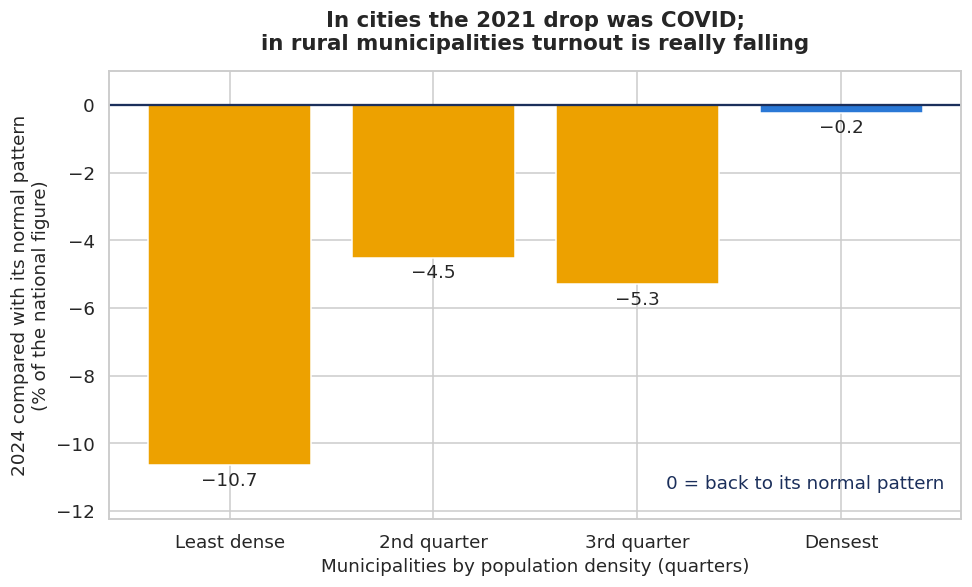

Densest quarter: -0.2% against its normal pattern; least dense quarter: -10.7%.
In cities the 2021 drop was COVID (back to normal in 2024); in rural municipalities turnout is really falling (still well below their normal pattern).


In [45]:
DENSITY_GROUPS = ["Least dense", "2nd quarter", "3rd quarter", "Densest"]
f26["density_group"] = pd.qcut(f26["pop_density"], 4, labels=DENSITY_GROUPS)
by_density = f26.groupby("density_group", observed=True).agg(
    municipalities=("muni_code", "size"),
    mean_rebound=("rebound", "mean"),
    share_recovered=("rebound", lambda s: (s > 0).mean()))
print(by_density.assign(mean_rebound=lambda t: (t["mean_rebound"] * 100).round(1),
                        share_recovered=lambda t: (t["share_recovered"] * 100).round()).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
vals = by_density["mean_rebound"] * 100
bars = ax.bar(DENSITY_GROUPS, vals, color=[AMBER, AMBER, AMBER, BLUE])
ax.bar_label(bars, labels=[f"{v:+.1f}".replace("-", "−") for v in vals], padding=4, fontsize=12)
ax.axhline(0, color=NAVY, lw=1.5)

# label for the zero line
ax.text(0.98, 0.06, "0 = back to its normal pattern", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=12, color=NAVY)

ax.set_ylim(vals.min() * 1.15, 1)            # a little room for the value labels
ax.set(ylabel="2024 compared with its normal pattern\n(% of the national figure)",
       xlabel="Municipalities by population density (quarters)")
ax.set_title("In cities the 2021 drop was COVID;\nin rural municipalities turnout is really falling",
             pad=14, fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES / "model_rebound_by_density.png", dpi=200, bbox_inches="tight")
plt.show()

densest, least = by_density.loc["Densest", "mean_rebound"] * 100, by_density.loc["Least dense", "mean_rebound"] * 100
print(f"Densest quarter: {densest:+.1f}% against its normal pattern; least dense quarter: {least:+.1f}%.")
if abs(densest) < 2 and least < -5:
    print("In cities the 2021 drop was COVID (back to normal in 2024); in rural municipalities turnout is really "
          "falling (still well below their normal pattern).")

## 9. What pushes each municipality up or down

Both of our linear models add up one part per feature (the feature's effect times how far the municipality is from
average), plus, in the hierarchical model, the province's part. These are factors that go together with turnout
rising or falling, not proven causes.

In [ ]:
if MAIN_MODEL == "hierarchical":
    scaler, coefs = final_model.scaler_, final_model.coef_
    f26["province_effect"] = f26["province"].map(final_model.group_effect_)
else:
    scaler, coefs = final_model[0], final_model[-1].coef_
LABELS = {"t_prev": "turnout last election", "r_prev_capped": "registration rate",
          "spatial_lag_prev": "neighbours' turnout", "log_density": "population density", "metro": "metro",
          "piped_water_rate": "piped water", "electricity_rate": "electricity",
          "refuse_removal_rate": "refuse removal", "higher_ed_rate": "higher education",
          "youth_share": "young adults' share", "services": "services", "province": "province"}
coef = pd.Series(coefs, index=FEATURES)

# 95% ranges: refit the model many times on resampled municipalities (as in section 3b)
N_BOOT_COEF = 300
codes = final_train["muni_code"].unique()
by_code = {c: g for c, g in final_train.groupby("muni_code")}
boot_coefs = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for _ in range(N_BOOT_COEF):
        b = pd.concat([by_code[c] for c in rng.choice(codes, len(codes))], ignore_index=True)
        if MAIN_MODEL == "hierarchical":
            boot_coefs.append(HierarchicalModel().fit(b[FEATURES], b["rel_change"], b["province"]).coef_)
        else:
            boot_coefs.append(ridge().fit(b[FEATURES], b["rel_change"])[-1].coef_)
ci = pd.DataFrame(np.quantile(boot_coefs, [0.025, 0.975], axis=0).T, index=FEATURES, columns=["low", "high"])
effects = pd.concat([coef.rename("effect"), ci], axis=1).mul(100).rename(index=LABELS).sort_values("effect")
print(effects.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 0.7 * len(effects) + 1.8))
y = np.arange(len(effects))
ax.barh(y, effects["effect"], color=np.where(effects["effect"] < 0, AMBER, BLUE), height=0.6)
ax.errorbar(effects["effect"], y, xerr=[effects["effect"] - effects["low"], effects["high"] - effects["effect"]],
            fmt="none", ecolor=NAVY, elinewidth=2, capsize=5)
ax.axvline(0, color=NAVY, lw=1.2)
ax.set_yticks(y, effects.index)
ax.set(xlabel=f"Effect on the change in turnout (points {PER_SD})", ylabel="",
       title="What the model links with turnout falling more (amber) or less (blue)\n"
             "than the national swing, with 95% ranges")
fig.text(0.01, -0.02, "Turnout last election: high-turnout places fell more, largely a pull back towards the "
         "average.\nNeighbours' turnout is negative for the same reason: high-turnout areas fell more.",
         fontsize=12, style="italic", va="top")
plt.tight_layout(); fig.savefig(FIGURES / "model_ridge_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()

# each feature's part = effect x how far the municipality is from average; together with the province part
# they add up to the municipality's adjustment
contrib = pd.DataFrame(scaler.transform(f26[FEATURES]) * coefs, columns=FEATURES, index=f26.index)

# water, electricity and refuse move together, so we show them as one group
SERVICES = [c for c in ["piped_water_rate", "electricity_rate", "refuse_removal_rate"] if c in FEATURES]
if len(SERVICES) > 1:
    contrib["services"] = contrib[SERVICES].sum(axis=1)
    contrib = contrib.drop(columns=SERVICES)

bars = contrib.rename(columns=LABELS)
if MAIN_MODEL == "hierarchical":
    bars["province"] = f26["province_effect"]
for c in bars:
    f26[f"contrib: {c}"] = bars[c]                        # saved for the dashboard's bars
f26["main_factor_down"] = contrib.idxmin(axis=1).where(contrib.min(axis=1) < 0).map(LABELS)
f26["main_factor_up"]   = contrib.idxmax(axis=1).where(contrib.max(axis=1) > 0).map(LABELS)
f26[["muni_code", "muni_name", "main_factor_down", "main_factor_up"]].head()

Reading the effects chart:
- Turnout at the last election is negative: places with high turnout last time fell more. That is mostly a pull back
  towards the average (very high or very low turnout tends not to repeat).
- Neighbours' turnout is negative too. This does not contradict Q6 in `07_eda` ("neighbours vote alike"), which is
  about the level of turnout. This chart is about the change, and high-turnout areas fell more.
- Bars whose 95% range crosses zero have no clear effect.
- The model did not beat the national-swing forecast on 2021, so these effects describe the past. They are not a
  proven way to rank municipalities for 2026.

## 10. Worse than expected

Municipalities whose turnout fell much more in 2021 than the model expected. Something local happened there that our
data cannot see, so they are worth a closer look.

In [ ]:
test_resid = (test["dt"] - pred_main).rename("unexplained")
worst = test_resid.nsmallest(15)
flag = df.loc[worst.index, ["muni_code", "muni_name", "province"]].assign(unexplained_points=(worst * 100).round(1))
print("Largest unexplained drops, 2016 -> 2021:")
print(flag.to_string(index=False))

f26["worse_than_expected_2021"] = f26["muni_code"].isin(flag["muni_code"]).astype(int)

## 11. Save the model and the forecasts

In [ ]:
import joblib

# save plain parts, so the file can be loaded without this notebook
if MAIN_MODEL == "hierarchical":
    saved_model = {"scaler": final_model.scaler_, "statsmodels_result": final_model.result_,
                   "province_effect": final_model.group_effect_}
else:
    saved_model = final_model

joblib.dump({"model": saved_model, "main_model": MAIN_MODEL, "features": FEATURES, "scenarios": SCENARIOS, "central": CENTRAL,
             "interval": (lo, hi)}, MODELS / "turnout_model.joblib")

out = f26[["muni_code", "muni_name", "province", "muni_category", "registered", "eligible_adults", "r",
           "t_prev", "adjustment",
           "t_2026_no_recovery", "t_2026_half_recovery", "t_2026_full_recovery", "t_2026_npe2024_signal",
           "t_2026_low", "t_2026", "t_2026_high", "t_2026_swing_low", "t_2026_swing", "t_2026_swing_high", "p_2026",
           "npe2024_turnout", "rebound", "t_2026_covid_recovery", "covid_status",
           "main_factor_down", "main_factor_up", "worse_than_expected_2021", "r_above_1_05"]
          + [c for c in f26.columns if c.startswith("contrib: ")]] \
    .rename(columns={"t_prev": "t_2021", "r": "r_2026", "registered": "registered_2026"}) \
    .sort_values("t_2026")

out.to_csv(PROCESSED / "predictions_2026.csv", index=False)
print(f"Saved {out.shape} to {PROCESSED / 'predictions_2026.csv'}")
out.head(10)

## Summary for the slides

- We predict the change in turnout, and test on a later election (2016 to 2021), never on random rows.
- Most of the change is national: the COVID drop moved every municipality at once. Knowing the national change cuts
  the error from about 9 points to about 3.
- Model check (trained on 2011 to 2016 only, with the national change given): the model does not beat the simple
  national-swing forecast, and after taking out the national change it puts municipalities in slightly the wrong
  order (see `model_check.csv`). In words: the model captures the national change, but differences between
  municipalities are hard to predict. The funnel, the four groups and the priority list do not depend on the model.
- So the dashboard shows the national-swing forecast: 2026 turnout = 2021 turnout + the change the 2024 national
  election points to, with a range from how far off this approach was on 2021.
- Our main model is a hierarchical (mixed-effects) regression. Ridge and LightGBM were tested the same way, and all
  of them are within a fraction of a point of each other.
- The 2026 national change is the biggest unknown, so we show scenarios. The main one comes from the 2024 national
  election and points to almost no recovery.
- Was 2021 just COVID? In the cities the drop was COVID (the densest quarter is back to normal). In rural
  municipalities turnout is really falling (the least dense are still about 10% below normal).
- No Census factor passed our tests. Better-serviced municipalities fell more in 2021 only, which points to COVID in
  urban places, not to services.
- Turnout at the last election and neighbours' turnout have negative effects, because high-turnout places fell more.

Limitations:
- With only one post-COVID election (2024) we cannot fully separate COVID from a longer fall in turnout.
- Stats SA did not release the Census 2022 employment and income data, so economic hardship is not in the model.
- The sample is small (213 municipalities, two past changes), a few small municipalities have registration rates
  above 1 because of the Census sample, and everything here is a link, not a cause.